In [ ]:
!pip install torch torchvision pandas pillow opencv-python matplotlib
!pip install diffusers transformers accelerate safetensors
!pip install segment-anything

In [1]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torch
import matplotlib.pyplot as plt
import numpy as np
from diffusers import AutoencoderKL

# -----------------------------
# Load attribute CSV (NOT landmarks)
# -----------------------------
csv_path = r"D:\7th sem\ADL\Project\Final project\data\list_attr_celeba.csv"

# Kaggle logic: index_col=0, convert -1/1 → 0/1
attr_df = pd.read_csv(csv_path, index_col=0)
attr_df = (attr_df + 1) // 2

print("Columns:", attr_df.columns[:])


class CelebASmall(Dataset):
    def __init__(self, img_dir, attr_df, limit=500, transform=None):
        self.img_dir = img_dir
        self.attr_df = attr_df
        self.filenames = attr_df.index[:limit]  # first 500 images
        self.transform = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        img_path = os.path.join(self.img_dir, fname)

        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        labels = self.attr_df.loc[fname].to_dict()
        return img, labels



img_dir = r"D:\7th sem\ADL\Project\Final project\data\img_align_celeba\img_align_celeba"

transform = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor(),
])

dataset = CelebASmall(
    img_dir=img_dir,
    attr_df=attr_df,
    limit=500,
    transform=transform
)

print("Using samples:", len(dataset))
loader = DataLoader(dataset, batch_size=1, shuffle=True)


c:\Users\Animesh Gupta\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Columns: Index(['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes',
       'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair',
       'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin',
       'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones',
       'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard',
       'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline',
       'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair',
       'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick',
       'Wearing_Necklace', 'Wearing_Necktie', 'Young'],
      dtype='object')
Using samples: 500


In [2]:
import numpy as np
import cv2
import torch
from segment_anything import sam_model_registry, SamPredictor

def interactive_sam_mask_from_tensor(img_tensor, checkpoint_path="sam_vit_b_01ec64.pth"):
    """
    Args:
        img_tensor: torch.Tensor (3, H, W) in [0,1] or [0,255]/255
    Returns:
        binary_mask: np.ndarray (H, W), uint8, 0 or 255
    """
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    if img_np.max() <= 1.0:
        img_np = (img_np * 255).astype(np.uint8)
    else:
        img_np = img_np.astype(np.uint8)

    sam = sam_model_registry["vit_b"](checkpoint=checkpoint_path)
    sam.to("cuda")
    predictor = SamPredictor(sam)

    clicked_point = [None]
    final_mask = [None]

    def mouse_callback(event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN:
            clicked_point[0] = (x, y)
            print("Clicked at:", clicked_point[0])

    cv2.namedWindow("Image", cv2.WINDOW_NORMAL)
    cv2.resizeWindow("Image", 1200, 800)   # width, height
    cv2.setMouseCallback("Image", mouse_callback)

    while True:
        display = cv2.cvtColor(img_np.copy(), cv2.COLOR_RGB2BGR)

        if clicked_point[0] is not None:
            predictor.set_image(img_np)
            input_points = np.array([clicked_point[0]])
            input_labels = np.array([1])
            masks, scores, logits = predictor.predict(
                point_coords=input_points,
                point_labels=input_labels,
                multimask_output=True
            )
            final_mask[0] = masks[np.argmax(scores)]
            overlay = img_np.copy()
            overlay[final_mask[0] > 0] = (0, 255, 0)
            display = cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)

        cv2.imshow("Image", display)
        key = cv2.waitKey(1)
        if key == 27:  # ESC
            break

    cv2.destroyAllWindows()

    del predictor
    del sam
    torch.cuda.empty_cache()

    if final_mask[0] is not None:
        binary_mask = (final_mask[0].astype(np.uint8)) * 255
        return binary_mask
    else:
        print("No mask was created.")
        return None
    

def brush_mask_from_tensor(img_tensor, brush_size=20):
    """
    Args:
        img_tensor: torch.Tensor (3, H, W) in [0,1] or [0,255]/255
        brush_size: radius of brush in pixels
    Returns:
        mask: np.ndarray (H, W), uint8, 0 or 255
    """

    # Convert tensor → numpy
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    if img_np.max() <= 1.0:
        img_np = (img_np * 255).astype(np.uint8)
    else:
        img_np = img_np.astype(np.uint8)

    # Mask initialized to zeros
    mask = np.zeros(img_np.shape[:2], dtype=np.uint8)

    drawing = False
    erasing = False

    def mouse_callback(event, x, y, flags, param):
        nonlocal drawing, erasing

        if event == cv2.EVENT_LBUTTONDOWN:
            drawing = True
        elif event == cv2.EVENT_LBUTTONUP:
            drawing = False

        if event == cv2.EVENT_RBUTTONDOWN:
            erasing = True
        elif event == cv2.EVENT_RBUTTONUP:
            erasing = False

        if drawing:
            cv2.circle(mask, (x, y), brush_size, 255, -1)
        if erasing:
            cv2.circle(mask, (x, y), brush_size, 0, -1)

    # Create window
    cv2.namedWindow("Brush Mask", cv2.WINDOW_NORMAL)
    cv2.resizeWindow("Brush Mask", 512, 512)
    cv2.setMouseCallback("Brush Mask", mouse_callback)

    while True:
        # Overlay mask on image
        overlay = img_np.copy()
        overlay[mask > 0] = (0, 255, 0)  # green mask overlay

        cv2.imshow("Brush Mask", overlay)
        key = cv2.waitKey(1)

        if key == 27:  # ESC
            break

    cv2.destroyAllWindows()
    return mask

Clicked at: (21, 33)


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

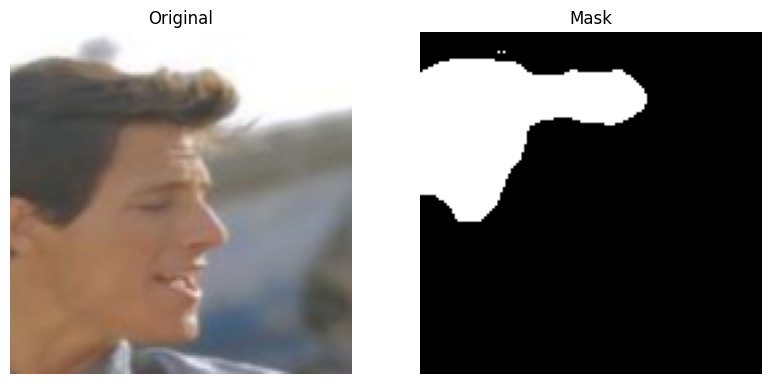

In [5]:
img_tensor,_ = dataset[2]


# 1) Interactive SAM mask
binary_mask = interactive_sam_mask_from_tensor(img_tensor)
#binary_mask = brush_mask_from_tensor(img_tensor, brush_size=3)

# 2) Prepare PIL image and mask for SD
# img_tensor is 0-1, convert back to 0-255 uint8
img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
img_np = (img_np * 255).astype(np.uint8)
pil_image = Image.fromarray(img_np).convert("RGB")

pil_mask = Image.fromarray(binary_mask).convert("L")

# 5) Show original, mask, and output
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(pil_image)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Mask")
plt.imshow(pil_mask, cmap="gray")
plt.axis("off")

In [6]:
from diffusers import StableDiffusionInpaintPipeline
import torch
from PIL import Image

def load_inpaint_pipeline():
    pipe = StableDiffusionInpaintPipeline.from_pretrained(
        "runwayml/stable-diffusion-inpainting",
        torch_dtype=torch.float16
    ).to("cuda")
    pipe.enable_attention_slicing("max")
    return pipe

def run_inpainting(pipe, pil_image, pil_mask, prompt, num_inference_steps=30, guidance_scale=10.5):
    result = pipe(   
        prompt=prompt,
        image=pil_image,
        mask_image=pil_mask,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale
    )
    return result.images[0]


In [7]:
import matplotlib.pyplot as plt

# Load SD inpainting pipeline once
pipe = load_inpaint_pipeline()

# Take one image from the dataloader
# for img_tensor, attrs, img_path in loader:
# img_tensor,_ = dataset[1]


# # 1) Interactive SAM mask
# binary_mask = interactive_sam_mask_from_tensor(img_tensor)

# # 2) Prepare PIL image and mask for SD
# # img_tensor is 0-1, convert back to 0-255 uint8
# img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
# img_np = (img_np * 255).astype(np.uint8)
# pil_image = Image.fromarray(img_np).convert("RGB")

# pil_mask = Image.fromarray(binary_mask).convert("L")

# # 3) Your prompt
# prompt = "add tiara on the head"  # you will set this

# # 4) Run inpainting
# out_image = run_inpainting(pipe, pil_image, pil_mask, prompt)

# # 5) Show original, mask, and output
# plt.figure(figsize=(15,5))
# plt.subplot(1,3,1)
# plt.title("Original")
# plt.imshow(pil_image)
# plt.axis("off")

# plt.subplot(1,3,2)
# plt.title("Mask")
# plt.imshow(pil_mask, cmap="gray")
# plt.axis("off")

# plt.subplot(1,3,3)
# plt.title("Inpainted")
# plt.imshow(out_image)
# plt.axis("off")
# plt.show()

# # break  # remove this to go over more images


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]An error occurred while trying to fetch C:\Users\Animesh Gupta\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\unet: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Animesh Gupta\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Loading pipeline components...:  57%|█████▋    | 4/7 [00:05<00:03,  1.06s/it]An error occurred while trying to fetch C:\Users\Animesh Gupta\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\vae: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Animesh Gupta\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainti

In [8]:
from diffusers import StableDiffusionInpaintPipeline

import torch
from typing import Union, List, Optional, Dict, Callable, Any

import inspect

import PIL.Image
import torch
from packaging import version
from transformers import CLIPImageProcessor, CLIPTextModel, CLIPTokenizer, CLIPVisionModelWithProjection

from diffusers.callbacks import MultiPipelineCallbacks, PipelineCallback
from diffusers.configuration_utils import FrozenDict
from diffusers.image_processor import PipelineImageInput, VaeImageProcessor
from diffusers.loaders import (
    FromSingleFileMixin,
    IPAdapterMixin,
    StableDiffusionLoraLoaderMixin,
    TextualInversionLoaderMixin,
)
from diffusers.models import (
    AsymmetricAutoencoderKL,
    AutoencoderKL,
    ImageProjection,
    UNet2DConditionModel,
)
from diffusers.models.lora import adjust_lora_scale_text_encoder
from diffusers.schedulers import KarrasDiffusionSchedulers
from diffusers.utils import (
    USE_PEFT_BACKEND,
    deprecate,
    is_torch_xla_available,
    logging,
    scale_lora_layers,
    unscale_lora_layers,
)
from diffusers.utils.torch_utils import randn_tensor
from diffusers.pipelines.pipeline_utils import DiffusionPipeline, StableDiffusionMixin
from diffusers.pipelines.stable_diffusion import StableDiffusionPipelineOutput
from diffusers.pipelines.stable_diffusion.safety_checker import StableDiffusionSafetyChecker
from diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_inpaint import retrieve_timesteps



class CustomPerturbedPipeline(StableDiffusionInpaintPipeline):
    # We override the __call__ method
    @torch.no_grad()
    def __call__(
        self,
        prompt: Union[str, List[str]] = None,
        image: PipelineImageInput = None,
        mask_image: PipelineImageInput = None,
        masked_image_latents: torch.Tensor = None,
        height: Optional[int] = None,
        width: Optional[int] = None,
        padding_mask_crop: Optional[int] = None,
        strength: float = 1.0,
        num_inference_steps: int = 50,
        timesteps: List[int] = None,
        sigmas: List[float] = None,
        guidance_scale: float = 7.5,
        negative_prompt: Optional[Union[str, List[str]]] = None,
        num_images_per_prompt: Optional[int] = 1,
        eta: float = 0.0,
        generator: Optional[Union[torch.Generator, List[torch.Generator]]] = None,
        latents: Optional[torch.Tensor] = None,
        prompt_embeds: Optional[torch.Tensor] = None,
        negative_prompt_embeds: Optional[torch.Tensor] = None,
        ip_adapter_image: Optional[PipelineImageInput] = None,
        ip_adapter_image_embeds: Optional[List[torch.Tensor]] = None,
        output_type: Optional[str] = "pil",
        return_dict: bool = True,
        cross_attention_kwargs: Optional[Dict[str, Any]] = None,
        clip_skip: int = None,
        callback_on_step_end: Optional[
            Union[Callable[[int, int, Dict], None], PipelineCallback, MultiPipelineCallbacks]
        ] = None,
        callback_on_step_end_tensor_inputs: List[str] = ["latents"],
        perturbation_function=None,
        **kwargs,
        ):
        
        callback = kwargs.pop("callback", None)
        callback_steps = kwargs.pop("callback_steps", None)

        if callback is not None:
            deprecate(
                "callback",
                "1.0.0",
                "Passing `callback` as an input argument to `__call__` is deprecated, consider use `callback_on_step_end`",
            )
        if callback_steps is not None:
            deprecate(
                "callback_steps",
                "1.0.0",
                "Passing `callback_steps` as an input argument to `__call__` is deprecated, consider use `callback_on_step_end`",
            )

        if isinstance(callback_on_step_end, (PipelineCallback, MultiPipelineCallbacks)):
            callback_on_step_end_tensor_inputs = callback_on_step_end.tensor_inputs

        # 0. Default height and width to unet
        height = height or self.unet.config.sample_size * self.vae_scale_factor
        width = width or self.unet.config.sample_size * self.vae_scale_factor

        # 1. Check inputs
        self.check_inputs(
            prompt,
            image,
            mask_image,
            height,
            width,
            strength,
            callback_steps,
            output_type,
            negative_prompt,
            prompt_embeds,
            negative_prompt_embeds,
            ip_adapter_image,
            ip_adapter_image_embeds,
            callback_on_step_end_tensor_inputs,
            padding_mask_crop,
        )

        self._guidance_scale = guidance_scale
        self._clip_skip = clip_skip
        self._cross_attention_kwargs = cross_attention_kwargs
        self._interrupt = False

        # 2. Define call parameters
        if prompt is not None and isinstance(prompt, str):
            batch_size = 1
        elif prompt is not None and isinstance(prompt, list):
            batch_size = len(prompt)
        else:
            batch_size = prompt_embeds.shape[0]

        device = self._execution_device

        # 3. Encode input prompt
        text_encoder_lora_scale = (
            cross_attention_kwargs.get("scale", None) if cross_attention_kwargs is not None else None
        )
        prompt_embeds, negative_prompt_embeds = self.encode_prompt(
            prompt,
            device,
            num_images_per_prompt,
            self.do_classifier_free_guidance,
            negative_prompt,
            prompt_embeds=prompt_embeds,
            negative_prompt_embeds=negative_prompt_embeds,
            lora_scale=text_encoder_lora_scale,
            clip_skip=self.clip_skip,
        )
        # For classifier free guidance, we need to do two forward passes.
        # Here we concatenate the unconditional and text embeddings into a single batch
        # to avoid doing two forward passes
        if self.do_classifier_free_guidance:
            prompt_embeds = torch.cat([negative_prompt_embeds, prompt_embeds])

        if ip_adapter_image is not None or ip_adapter_image_embeds is not None:
            image_embeds = self.prepare_ip_adapter_image_embeds(
                ip_adapter_image,
                ip_adapter_image_embeds,
                device,
                batch_size * num_images_per_prompt,
                self.do_classifier_free_guidance,
            )

        # 4. set timesteps
        timesteps, num_inference_steps = retrieve_timesteps(
            self.scheduler, num_inference_steps, device, timesteps, sigmas
        )
        timesteps, num_inference_steps = self.get_timesteps(
            num_inference_steps=num_inference_steps, strength=strength, device=device
        )
        # check that number of inference steps is not < 1 - as this doesn't make sense
        if num_inference_steps < 1:
            raise ValueError(
                f"After adjusting the num_inference_steps by strength parameter: {strength}, the number of pipeline"
                f"steps is {num_inference_steps} which is < 1 and not appropriate for this pipeline."
            )
        # at which timestep to set the initial noise (n.b. 50% if strength is 0.5)
        latent_timestep = timesteps[:1].repeat(batch_size * num_images_per_prompt)
        # create a boolean to check if the strength is set to 1. if so then initialise the latents with pure noise
        is_strength_max = strength == 1.0

        # 5. Preprocess mask and image

        if padding_mask_crop is not None:
            crops_coords = self.mask_processor.get_crop_region(mask_image, width, height, pad=padding_mask_crop)
            resize_mode = "fill"
        else:
            crops_coords = None
            resize_mode = "default"

        original_image = image
        init_image = self.image_processor.preprocess(
            image, height=height, width=width, crops_coords=crops_coords, resize_mode=resize_mode
        )
        init_image = init_image.to(dtype=torch.float32)

        # 6. Prepare latent variables
        num_channels_latents = self.vae.config.latent_channels
        num_channels_unet = self.unet.config.in_channels
        return_image_latents = num_channels_unet == 4

        latents_outputs = self.prepare_latents(
            batch_size * num_images_per_prompt,
            num_channels_latents,
            height,
            width,
            prompt_embeds.dtype,
            device,
            generator,
            latents,
            image=init_image,
            timestep=latent_timestep,
            is_strength_max=is_strength_max,
            return_noise=True,
            return_image_latents=return_image_latents,
        )

        if return_image_latents:
            latents, noise, image_latents = latents_outputs
        else:
            latents, noise = latents_outputs

        # 7. Prepare mask latent variables
        mask_condition = self.mask_processor.preprocess(
            mask_image, height=height, width=width, resize_mode=resize_mode, crops_coords=crops_coords
        )

        if masked_image_latents is None:
            masked_image = init_image * (mask_condition < 0.5)
        else:
            masked_image = masked_image_latents

        mask, masked_image_latents = self.prepare_mask_latents(
            mask_condition,
            masked_image,
            batch_size * num_images_per_prompt,
            height,
            width,
            prompt_embeds.dtype,
            device,
            generator,
            self.do_classifier_free_guidance,
        )
        # ================================================================================
        # modified this part to add perturbation

        if perturbation_function is not None:
            print("Applying perturbation to latents...")
            masked_image_latents = perturbation_function(masked_image_latents)
        # ================================================================================

        # 8. Check that sizes of mask, masked image and latents match
        if num_channels_unet == 9:
            # default case for stable-diffusion-v1-5/stable-diffusion-inpainting
            num_channels_mask = mask.shape[1]
            num_channels_masked_image = masked_image_latents.shape[1]
            if num_channels_latents + num_channels_mask + num_channels_masked_image != self.unet.config.in_channels:
                raise ValueError(
                    f"Incorrect configuration settings! The config of `pipeline.unet`: {self.unet.config} expects"
                    f" {self.unet.config.in_channels} but received `num_channels_latents`: {num_channels_latents} +"
                    f" `num_channels_mask`: {num_channels_mask} + `num_channels_masked_image`: {num_channels_masked_image}"
                    f" = {num_channels_latents + num_channels_masked_image + num_channels_mask}. Please verify the config of"
                    " `pipeline.unet` or your `mask_image` or `image` input."
                )
        elif num_channels_unet != 4:
            raise ValueError(
                f"The unet {self.unet.__class__} should have either 4 or 9 input channels, not {self.unet.config.in_channels}."
            )

        # 9. Prepare extra step kwargs. TODO: Logic should ideally just be moved out of the pipeline
        extra_step_kwargs = self.prepare_extra_step_kwargs(generator, eta)

        # 9.1 Add image embeds for IP-Adapter
        added_cond_kwargs = (
            {"image_embeds": image_embeds}
            if ip_adapter_image is not None or ip_adapter_image_embeds is not None
            else None
        )

        # 9.2 Optionally get Guidance Scale Embedding
        timestep_cond = None
        if self.unet.config.time_cond_proj_dim is not None:
            guidance_scale_tensor = torch.tensor(self.guidance_scale - 1).repeat(batch_size * num_images_per_prompt)
            timestep_cond = self.get_guidance_scale_embedding(
                guidance_scale_tensor, embedding_dim=self.unet.config.time_cond_proj_dim
            ).to(device=device, dtype=latents.dtype)

        # 10. Denoising loop
        num_warmup_steps = len(timesteps) - num_inference_steps * self.scheduler.order
        self._num_timesteps = len(timesteps)
        with self.progress_bar(total=num_inference_steps) as progress_bar:
            for i, t in enumerate(timesteps):
                if self.interrupt:
                    continue

                # expand the latents if we are doing classifier free guidance
                latent_model_input = torch.cat([latents] * 2) if self.do_classifier_free_guidance else latents

                # concat latents, mask, masked_image_latents in the channel dimension
                latent_model_input = self.scheduler.scale_model_input(latent_model_input, t)

                if num_channels_unet == 9:
                    latent_model_input = torch.cat([latent_model_input, mask, masked_image_latents], dim=1)

                # predict the noise residual
                noise_pred = self.unet(
                    latent_model_input,
                    t,
                    encoder_hidden_states=prompt_embeds,
                    timestep_cond=timestep_cond,
                    cross_attention_kwargs=self.cross_attention_kwargs,
                    added_cond_kwargs=added_cond_kwargs,
                    return_dict=False,
                )[0]

                # perform guidance
                if self.do_classifier_free_guidance:
                    noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
                    noise_pred = noise_pred_uncond + self.guidance_scale * (noise_pred_text - noise_pred_uncond)

                # compute the previous noisy sample x_t -> x_t-1
                latents = self.scheduler.step(noise_pred, t, latents, **extra_step_kwargs, return_dict=False)[0]
                if num_channels_unet == 4:
                    init_latents_proper = image_latents
                    if self.do_classifier_free_guidance:
                        init_mask, _ = mask.chunk(2)
                    else:
                        init_mask = mask

                    if i < len(timesteps) - 1:
                        noise_timestep = timesteps[i + 1]
                        init_latents_proper = self.scheduler.add_noise(
                            init_latents_proper, noise, torch.tensor([noise_timestep])
                        )

                    latents = (1 - init_mask) * init_latents_proper + init_mask * latents

                if callback_on_step_end is not None:
                    callback_kwargs = {}
                    for k in callback_on_step_end_tensor_inputs:
                        callback_kwargs[k] = locals()[k]
                    callback_outputs = callback_on_step_end(self, i, t, callback_kwargs)

                    latents = callback_outputs.pop("latents", latents)
                    prompt_embeds = callback_outputs.pop("prompt_embeds", prompt_embeds)
                    negative_prompt_embeds = callback_outputs.pop("negative_prompt_embeds", negative_prompt_embeds)
                    mask = callback_outputs.pop("mask", mask)
                    masked_image_latents = callback_outputs.pop("masked_image_latents", masked_image_latents)

                # call the callback, if provided
                if i == len(timesteps) - 1 or ((i + 1) > num_warmup_steps and (i + 1) % self.scheduler.order == 0):
                    progress_bar.update()
                    if callback is not None and i % callback_steps == 0:
                        step_idx = i // getattr(self.scheduler, "order", 1)
                        callback(step_idx, t, latents)

                # if XLA_AVAILABLE:
                #     xm.mark_step()

        if not output_type == "latent":
            condition_kwargs = {}
            if isinstance(self.vae, AsymmetricAutoencoderKL):
                init_image = init_image.to(device=device, dtype=masked_image_latents.dtype)
                init_image_condition = init_image.clone()
                init_image = self._encode_vae_image(init_image, generator=generator)
                mask_condition = mask_condition.to(device=device, dtype=masked_image_latents.dtype)
                condition_kwargs = {"image": init_image_condition, "mask": mask_condition}
            image = self.vae.decode(
                latents / self.vae.config.scaling_factor, return_dict=False, generator=generator, **condition_kwargs
            )[0]
            image, has_nsfw_concept = self.run_safety_checker(image, device, prompt_embeds.dtype)
        else:
            image = latents
            has_nsfw_concept = None

        if has_nsfw_concept is None:
            do_denormalize = [True] * image.shape[0]
        else:
            do_denormalize = [not has_nsfw for has_nsfw in has_nsfw_concept]

        image = self.image_processor.postprocess(image, output_type=output_type, do_denormalize=do_denormalize)

        if padding_mask_crop is not None:
            image = [self.image_processor.apply_overlay(mask_image, original_image, i, crops_coords) for i in image]

        # Offload all models
        self.maybe_free_model_hooks()

        if not return_dict:
            return (image, has_nsfw_concept)

        return StableDiffusionPipelineOutput(images=image, nsfw_content_detected=has_nsfw_concept)

In [9]:
# Assuming 'pipe' is your currently loaded pipeline
new_pipe = CustomPerturbedPipeline(
    vae=pipe.vae,
    text_encoder=pipe.text_encoder,
    tokenizer=pipe.tokenizer,
    unet=pipe.unet,
    scheduler=pipe.scheduler,
    safety_checker=pipe.safety_checker,
    feature_extractor=pipe.feature_extractor,
    image_encoder=None 
)
new_pipe = new_pipe.to("cuda")

In [10]:
device = "cuda"
vae = AutoencoderKL.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    subfolder="vae"
).to(device)

latents = []
labels = []
#attribute_key = "Black_Hair"
#attribute_key = "Smiling"
#attribute_key = "Wearing_Necklace"
attribute_key = "Wavy_Hair"
max_images = 1000

for i, (img, attr_dict) in enumerate(dataset):
    if i >= max_images:
        break

    img_resized = T.Resize((512, 512))(img).unsqueeze(0).to(device)

    with torch.no_grad():
        z = vae.encode(img_resized).latent_dist.sample() * 0.18215

    latents.append(z.flatten().cpu().numpy())

    label = int(attr_dict[attribute_key])
    labels.append(label)

    if i % 100 == 0:
        print(f"Encoded {i}")


X = np.array(latents)
y = np.array(labels)


Encoded 0
Encoded 100
Encoded 200
Encoded 300
Encoded 400


In [11]:
from sklearn.linear_model import LinearRegression

def train_causal_probe(k=60):
    probe = LinearRegression()
    probe.fit(X, y)

    importance = np.abs(probe.coef_)
    S_indices = np.argsort(importance)[-k:]

    print(f"Probe trained. Top-k subspace: {k} dims, mean coef: {importance[S_indices].mean():.3f}")
    return probe, S_indices, X.shape[1]

probe, S_indices, flat_dim = train_causal_probe()  

Probe trained. Top-k subspace: 60 dims, mean coef: 0.006


In [12]:
def my_perturbation(latents, k=30, alpha=0.8):

    B = latents.shape[0]

    # Flatten latents: (B, 4*64*64)
    z_flat = latents.view(B, -1)

    # Extract top-k direction from probe
    coef = torch.tensor(probe.coef_[S_indices[:k]], device=latents.device, dtype=latents.dtype)

    # Normalize direction for smoother edits
    direction = coef / (coef.norm() + 1e-8)

    # Expand direction to batch
    direction = direction.unsqueeze(0).expand(B, -1)

    # Apply perturbation
    z_flat[:, S_indices[:k]] += alpha * direction

    # Reshape back to latent shape
    return z_flat.view(B, 4, 64, 64)


Clicked at: (29, 29)
Clicked at: (72, 25)


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

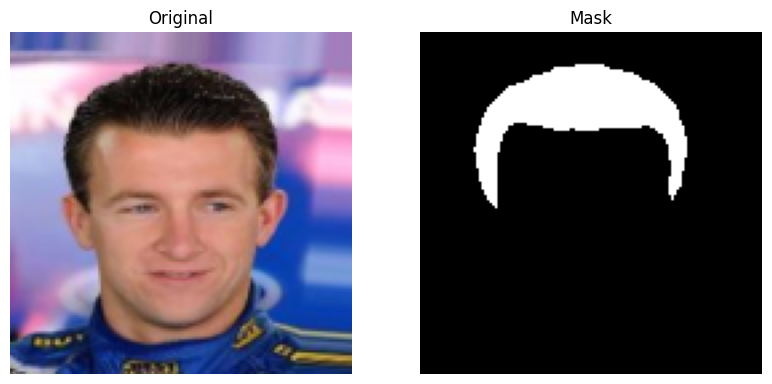

In [13]:
img_tensor,_ = dataset[22]  # smiling example
#img_tensor,_ = dataset[1]  # black hair example


# 1) Interactive SAM mask
binary_mask = interactive_sam_mask_from_tensor(img_tensor)
#binary_mask = brush_mask_from_tensor(img_tensor, brush_size=3)

# 2) Prepare PIL image and mask for SD
# img_tensor is 0-1, convert back to 0-255 uint8
img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
img_np = (img_np * 255).astype(np.uint8)
pil_image = Image.fromarray(img_np).convert("RGB")

pil_mask = Image.fromarray(binary_mask).convert("L")

# 5) Show original, mask, and output
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(pil_image)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Mask")
plt.imshow(pil_mask, cmap="gray")
plt.axis("off")

In [14]:
# prompt = "a smiling woman with long black hair(not red) totally realistic photo, high quality, totally black hair"
# negative_prompt = "blonde hair, brown hair, red hair, gray hair, white hair, silver hair, artifacts"
# prompt = "add a big smile"
# negative_prompt = "neutral expression, frown, sad, angry, artifacts"

# prompt = "add a necklace on the neck of the woman"
# negative_prompt = "no necklace, artifacts"

prompt = "make the hair wavy "
negative_prompt = "straight hair, artifacts"

Applying perturbation to latents...


100%|██████████| 32/32 [00:06<00:00,  4.80it/s]


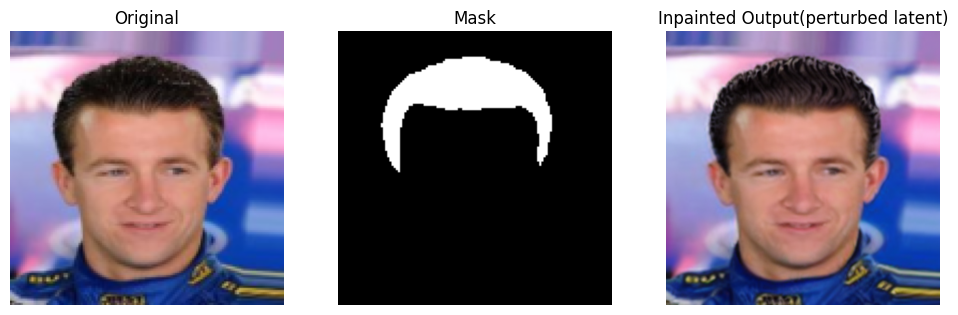

In [15]:

result_image = new_pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=pil_image,
    mask_image=pil_mask,
    strength=0.65,
    guidance_scale=12,
    perturbation_function=my_perturbation
).images[0]

plt.figure(figsize=(12,4))

# Original
plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(pil_image)
plt.axis("off")

# Mask
plt.subplot(1,3,2)
plt.title("Mask")
plt.imshow(pil_mask, cmap="gray")
plt.axis("off")

# Output
plt.subplot(1,3,3)
plt.title("Inpainted Output(perturbed latent)")
plt.imshow(result_image)
plt.axis("off")

plt.show()


100%|██████████| 37/37 [00:07<00:00,  4.90it/s]


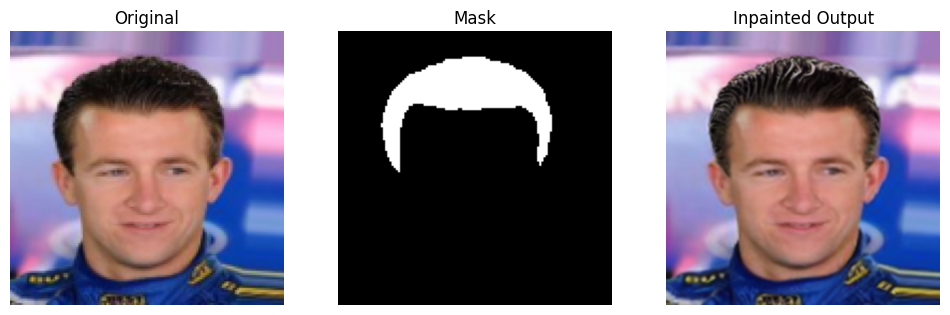

In [16]:
result_image = new_pipe(
    prompt=prompt,
    image=pil_image,
    negative_prompt=negative_prompt,
    mask_image=pil_mask,
    strength=0.75,
    guidance_scale=12,
    perturbation_function=None
).images[0]

plt.figure(figsize=(12,4))

# Original
plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(pil_image)
plt.axis("off")

# Mask
plt.subplot(1,3,2)
plt.title("Mask")
plt.imshow(pil_mask, cmap = "gray")
plt.axis("off")

# Output
plt.subplot(1,3,3)
plt.title("Inpainted Output")
plt.imshow(result_image)
plt.axis("off")

plt.show()
